# **0 - Tipos de Machine Learning**

El Machine Learning es el área de la IA que se encarga en conseguir que la "inteligencia", se consiga a través del aprendizaje en base a datos. Sin embargo, este concepto es muy general. En la práctica cuando creamos un modelo de Machine Learning se crear para resolver un problema concreto.

<br>

## **Tipos de ML según su Tarea**


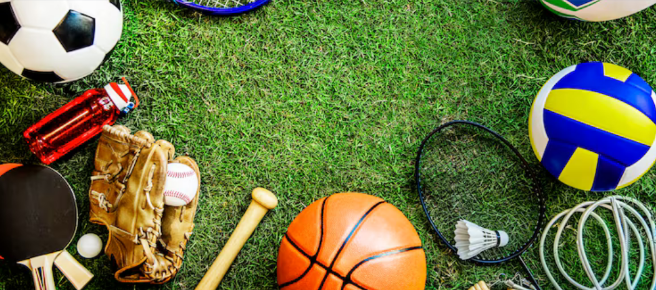

Se denomina "tarea" al objetivo que tiene una IA para resolver un problema concreto. Por ejemplo, un modelo de ML capaz de capaz de escribir una novela en español tendría la tarea de "generación de texto". Existen una infinidad de tareas, sin embargo, algunas muy recurrentes del Machine Learning sin las siguientes:

* **Regresión**
* **Clasificación**
* **Clusterización**
* **Reducción de dimensionalidad**
* **Forecasting**

<br>

## **Tipos de ML en NLP**

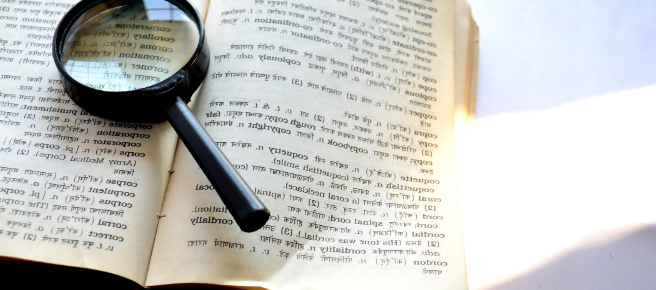

Las tareas pueden ser más específicas cuando aplican a un dominio concreto. Por ejemplo, algunas tareas de Machine Learning dentro del ámbito del procesamiento de lenguaje natural son las siguientes

* **Generación Text2text**
* **Clasificación de texto**
* **Clasificación de palabras/subpalabras**
* **Resumir**
* **Grafos de conocimiento**

<br>

## **Tipos de ML según su aprendizaje**

Como hemos denominado, el Machine Learning es el área de la IA que obtiene conocimiento en base a datos, sin embargo, existen diferentes formar por las cuales se puede extraer conocimiento de los datos. Según la forma en la el modelo aprende en base a los datos, existe la siguiente taxonomía:

<br>

### **Aprendizaje Supervisado**



Los modelos de aprendizaje supervisado se caracterizan por necesitar datos **datos etiquetados**, o lo que es lo mismo necesitamos que existe una variable a predecir **target** con respecto a unas **variables** (como vimos en la sesión anterior). Esto generalmente está relacionado con modelos cuya tarea está relacionada con "adivinar" una variable en base a otras.

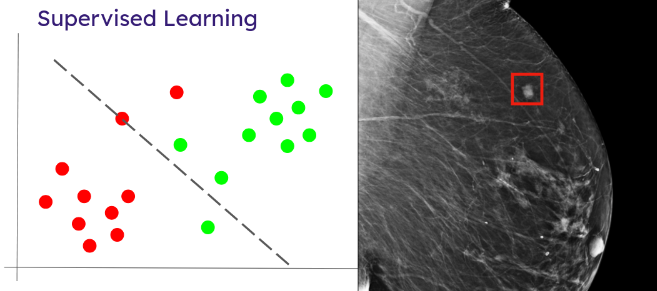

<br>

### **Aprendizaje No Supervisado**



Estos modelos no requieren de datos etiquetados, sino que se suelen usar justamente para eso, cuando necesitas "etiquetar los datos" en categorías que desconoces.

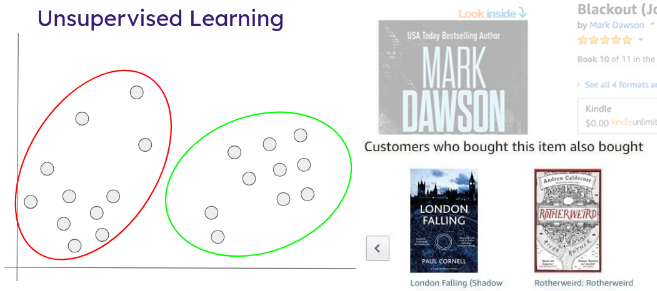

<br>

### **Aprendizaje por refuerzo**


Este tipo de modelos son similares al aprendizaje supervisado, solo que no aprenden a partir de una variable a predecir, sino que dan una predicción, evaluan si ha ido bien o mal y en base a ello aprenden (p.e. un modelo que aprende a jugar al ajedrez a partir de jugar muchas veces y ver si pierde o gana)

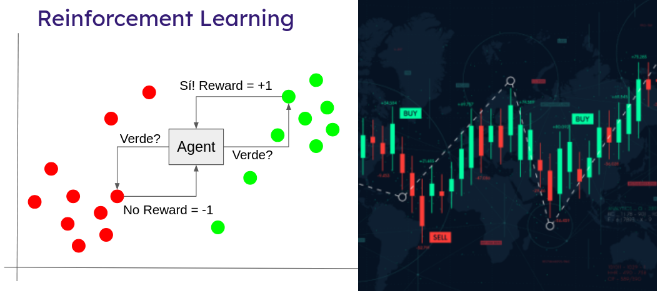

> **NOTA**: *La clasificación de modelos en base a la tareas y en base al aprendizaje no son independientes entre sí, sino que para determinados tipos de aprendizaje existen determinados tipos de tarea que se pueden hacer*

<br>

# **1. - Regresión - Aprendizaje Supervisado**

![]( 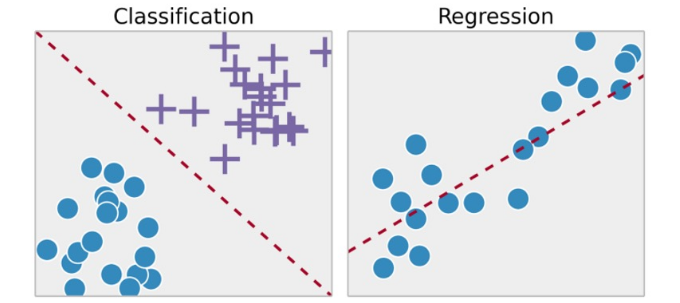)

## **1.1. - Introducción**

Los modelos de este tipo de tarea pertenecen además a la categorías de modelos de **aprendizaje supervisado** tienen como objetivo predecir una **VARIABLE NUMÉRICA CONTINUA**



<Axes: xlabel='Horas de estudio', ylabel='Nota'>

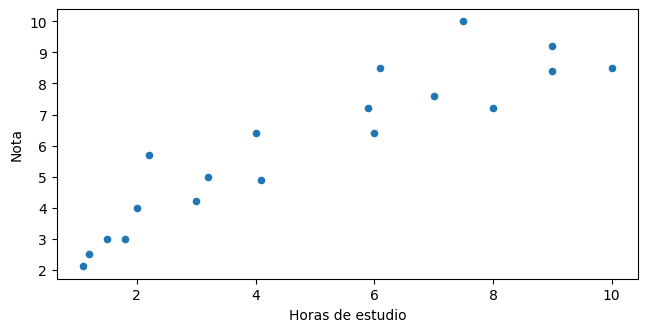

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

data = pd.DataFrame([
    {"Clase":"A","Horas de estudio":1.1,"Nota":2.1},
    {"Clase":"A","Horas de estudio":1.2,"Nota":2.5},
    {"Clase":"A","Horas de estudio":1.5,"Nota":3.0},
    {"Clase":"A","Horas de estudio":8.0,"Nota":7.2},
    {"Clase":"A","Horas de estudio":3.2,"Nota":5.0},
    {"Clase":"A","Horas de estudio":5.9,"Nota":7.2},
    {"Clase":"A","Horas de estudio":4.1,"Nota":4.9},
    {"Clase":"B","Horas de estudio":9.0,"Nota":8.4},
    {"Clase":"B","Horas de estudio":6.0,"Nota":6.4},
    {"Clase":"B","Horas de estudio":3.0,"Nota":4.2},
    {"Clase":"B","Horas de estudio":2.0,"Nota":4.0},
    {"Clase":"B","Horas de estudio":2.2,"Nota":5.7},
    {"Clase":"B","Horas de estudio":1.8,"Nota":3.0},
    {"Clase":"C","Horas de estudio":4.0,"Nota":6.4},
    {"Clase":"C","Horas de estudio":6.1,"Nota":8.5},
    {"Clase":"C","Horas de estudio":7.5,"Nota":10.0},
    {"Clase":"C","Horas de estudio":7.0,"Nota":7.6},
    {"Clase":"C","Horas de estudio":9.0,"Nota":9.2},
    {"Clase":"C","Horas de estudio":10.0,"Nota":8.5}
])

data.plot(kind='scatter',x="Horas de estudio",y="Nota")

El modelo aprende a predecir la variable continua

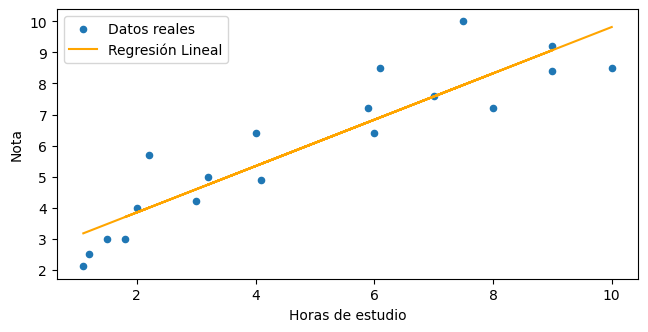

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(
    X=data[["Horas de estudio"]],
    y=data["Nota"]
)

# 1. Generar predicciones
data["Prediccion"] = model.predict(data[["Horas de estudio"]])

# 2. Graficar datos originales (puntos)
ax = data.plot.scatter(x="Horas de estudio", y="Nota", label="Datos reales")

# 3. Graficar línea de regresión
data.plot(x="Horas de estudio", y="Prediccion", color="orange", ax=ax, label="Regresión Lineal")

plt.show()

Dentro de esta catergoría existen muchos modelos distintos con diferentes configuraciones, implementaciones matemáticas, librerías,... por ello vamos a centrarnos en solamente 3 modelos concretos que son bastante populares para explicar el concepto de modelos de Regresión y ver diferentes aproximaciones a este problema.

> **Nota**: En el caso de querer investigar más sobre este tema o ver otros modelos dejamos la [siguiente documentación ](https://scikit-learn.org/1.5/supervised_learning.html).



<br>

## **1.2. - Evaluación**

En la lección anterior comentamos que una de las formas para medir la calidad de la regresión lineal era el coeficiente R2. Vamos a entrar un poco más en detalle en cómo se evalua. El objetivo de la evaluzación es medir cómo de bien se ajusta la predicción al valor real


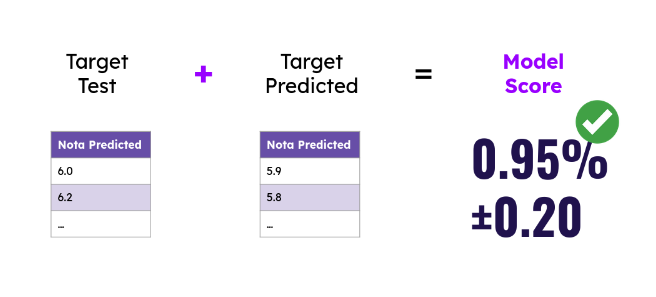

In [ ]:
y_true = data["Nota"]
y_pred = data["Prediccion"]

### **Función de Loss**

Función que usa el algoritmo durante el entrenamiento para aprender. Esta función mide "cuánto se equivoca" y en cada iteración "guia" al modelo para que mejore (como los renglones ayudan a guiar el boli)

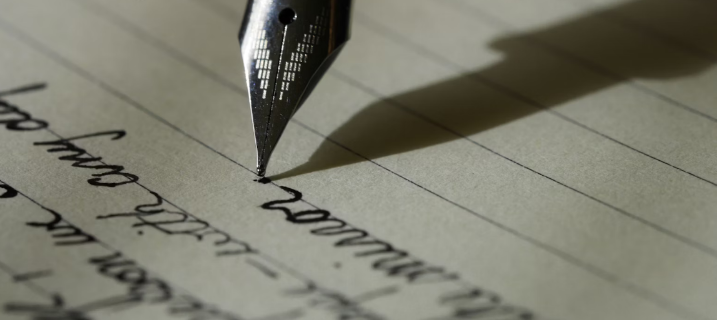

Algunas funciones de loss que se usan para los modelos de regresión son las siguientes:

* **Mean Squared Error** <- la más común

* **Mean Absolute Error**

* **Poisson Deviance**

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_poisson_deviance

print("Mean squared error:\t",mean_squared_error(y_true,y_pred))
print("Mean absolute error:\t",mean_absolute_error(y_true,y_pred))
print("Mean Poisson error:\t",mean_poisson_deviance(y_true,y_pred))

Mean squared error:	 0.9237094329049443
Mean absolute error:	 0.7815682726296522
Mean Poisson error:	 0.15965382762361244


> **NOTA**: *Usar una u otra métrica de error depende de la distribución estadística que sigan los datos, pero no vamos a profundizar en ese tema en esta clase*

### **Métricas**

Función que mide cómo de bien funciona un algoritmo entrenado. Esta función no se usa para aprender sino solo para medir

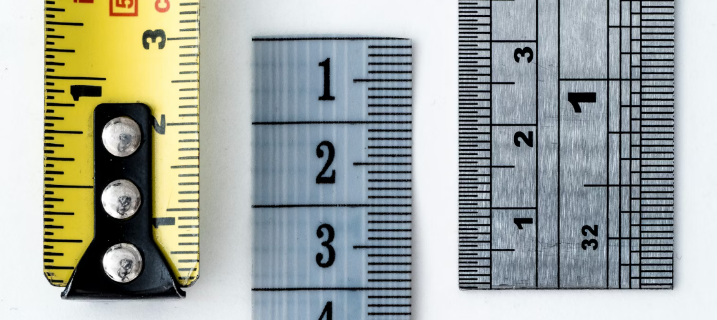

Algunos ejemplos son:

* **R2 score**

* **Percentage Error**

* **Max Error**

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import max_error
from sklearn.metrics import mean_absolute_percentage_error

print("R2 Score:\t\t",r2_score(y_true,y_pred))
print("Max error:\t\t",mean_absolute_error(y_true,y_pred))
print("Percentage Error:\t",mean_poisson_deviance(y_true,y_pred))

R2 Score:		 0.8332621104661808
Max error:		 0.7815682726296522
Percentage Error:	 0.15965382762361244


> **NOTA**: Hay veces que funciones de loss son usadas como métricas. Para leer más sobre qué métricas existen y cuándo usarlas leer esta [documentacion](https://scikit-learn.org/stable/modules/model_evaluation.html)

<br>

## **1.3 - Modelos**

### Dataset - Concrete Strength

**Cargar los datos**

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/concrete.csv'
data = pd.read_csv(url)

data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


**Train-Test split**

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("strength", axis=1)
y = data[["strength"]]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)


<br>

### **RandomForest Regressor**

Es un algoritmo que se basa en lo que se denomina **Árboles de decisión**. A diferencia de la Regresión Lineal, los Árboles de decisión no buscan aproximar los datos a una recta sino más bien en hacer "decisiones binarias" (por seguir una analogía, esto es similar a jugar al "quien es quién"). El algoritmo **RandomForest** lo que hace es combinar muchos de esos árboles en un solo modelo

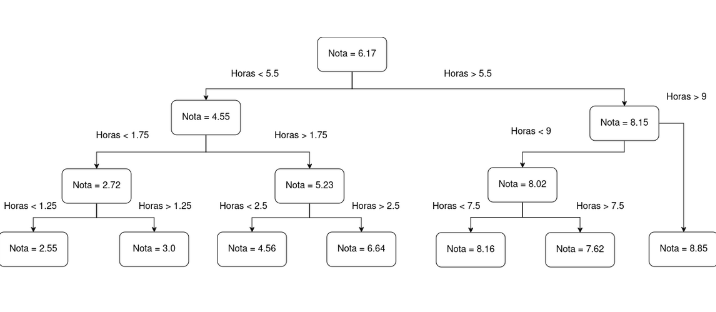

**Entrenamiento**

In [ ]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    n_estimators=1,            # Número de árboles (100-1000)
    criterion="squared_error",   # Función de loss (squared_error casi siempre)
    max_depth=1000,              # Profundidad máxima de cada árbol (5-15)
    min_samples_leaf=1,          # Nº mínimo de datos por nodo (2-10)
).fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


**Predicción**

In [ ]:
y_pred = model.predict(X_test)

print(y_test.values.tolist())
print(y_pred.tolist())

[[31.72], [14.5], [18.0], [7.68], [28.3], [44.61], [36.15], [7.4], [24.39], [68.75], [7.72], [57.21], [65.2], [60.29], [28.63], [19.52], [13.46], [34.4], [15.57], [35.08], [17.28], [46.93], [9.85], [44.42], [11.39], [9.87], [33.94], [40.68], [26.23], [21.92], [74.17], [33.42], [57.22], [29.79], [19.69], [67.87], [37.36], [22.75], [31.35], [13.12], [54.32], [22.93], [15.42], [78.8], [39.0], [49.2], [43.7], [49.8], [60.29], [51.26], [17.54], [42.13], [74.36], [11.48], [35.3], [33.72], [16.89], [45.37], [50.46], [9.74], [10.35], [22.53], [50.77], [56.34], [33.76], [29.39], [26.2], [21.86], [41.54], [22.95], [29.87], [76.8], [47.28], [32.07], [17.58], [32.72], [37.17], [30.23], [44.33], [23.84], [33.19], [35.85], [22.63], [22.49], [39.05], [45.84], [40.87], [66.7], [45.94], [30.57], [11.47], [47.03], [62.5], [23.64], [56.14], [44.39], [15.69], [29.59], [29.07], [24.29], [24.4], [53.69], [25.2], [38.02], [35.23], [16.28], [39.32], [47.97], [56.1], [18.91], [38.7], [27.68], [37.33], [41.89],

**Evaluación**

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print('r2 score', r2_score(y_test,y_pred))
print('rmse', root_mean_squared_error(y_test,y_pred))

r2 score 0.8260910297792556
rmse 7.251878573156463


**Características**

* **No** requiere escalar las variables

* **No** requier corregir outliers

* **Sí** tiene problemas para extrapolar

> **Real World Tip**: Aunque la teoría de Machine Learning dice que para cada problema deberíamos encontrar el modelo que mejor funciona para ese problema en particular, la realidad es que el modelo de RandomForest es el que mejor funciona pada datos de la vida real

<br>

### **K-Nearest Neightbour (KNN)**

Este tipo de algoritmo, a diferencia de la regresión lineal o de los árboles de decisión, no busca ajustar una recta o un conjunto de decisiones como la regresión lineal o los árboles de decisión. En este caso, KNN busca los K datos más próximos a uno dado y estima que la predicción es la media de todos esos valores.

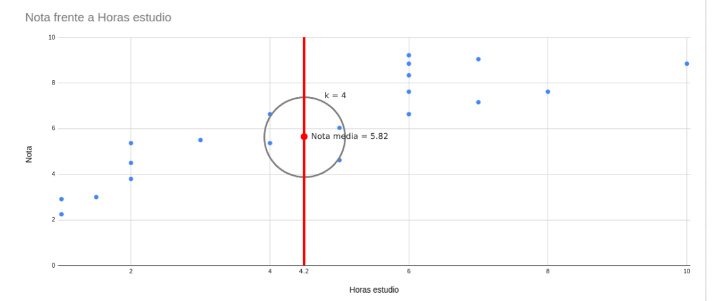

**Entrenamiento**

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor


model = KNeighborsRegressor(
    n_neighbors=5,             # Número de "vecinos" a tener en cuenta (3-20)
    weights="uniform",         # Importancia de cada dato (uniforme)
    p=2,                       # Potencia de la distancia (casi siempre 1 o 2)
).fit(X_train,y_train)

**Predicción**

In [ ]:
y_pred = model.predict(X_test)

print(y_test.values.tolist())
print(y_pred.tolist())

[[31.72], [14.5], [18.0], [7.68], [28.3], [44.61], [36.15], [7.4], [24.39], [68.75], [7.72], [57.21], [65.2], [60.29], [28.63], [19.52], [13.46], [34.4], [15.57], [35.08], [17.28], [46.93], [9.85], [44.42], [11.39], [9.87], [33.94], [40.68], [26.23], [21.92], [74.17], [33.42], [57.22], [29.79], [19.69], [67.87], [37.36], [22.75], [31.35], [13.12], [54.32], [22.93], [15.42], [78.8], [39.0], [49.2], [43.7], [49.8], [60.29], [51.26], [17.54], [42.13], [74.36], [11.48], [35.3], [33.72], [16.89], [45.37], [50.46], [9.74], [10.35], [22.53], [50.77], [56.34], [33.76], [29.39], [26.2], [21.86], [41.54], [22.95], [29.87], [76.8], [47.28], [32.07], [17.58], [32.72], [37.17], [30.23], [44.33], [23.84], [33.19], [35.85], [22.63], [22.49], [39.05], [45.84], [40.87], [66.7], [45.94], [30.57], [11.47], [47.03], [62.5], [23.64], [56.14], [44.39], [15.69], [29.59], [29.07], [24.29], [24.4], [53.69], [25.2], [38.02], [35.23], [16.28], [39.32], [47.97], [56.1], [18.91], [38.7], [27.68], [37.33], [41.89],

**Evaluación**

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print('r2 score', r2_score(y_test,y_pred))
print('rmse', root_mean_squared_error(y_test,y_pred))

r2 score 0.7064016680689011
rmse 9.422503853742189


**Características**

* **Sí** requiere escalar las variables

* **No** requiere corregir outliers

* **Sí** tiene problemas para extrapolar

<br>

### **Support Vector Machine (SVM)**

Este tipo de algoritmo es similar a la regresión lineal. Busca encontrar la ecuación matemática que mejor se ajusta a los puntos, solo que en el caso de SVM, permite más libertad que la regresión lineal. No tienen por qué ajustarse a una recta

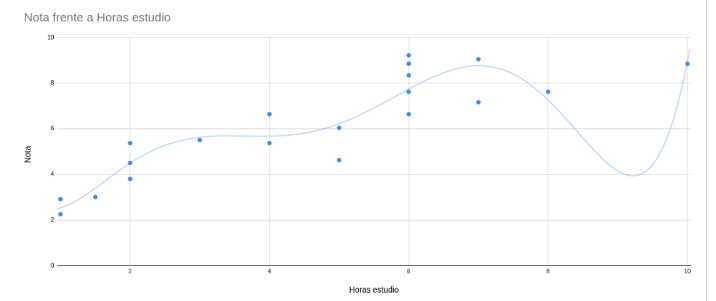

**Entrenamiento**

In [ ]:
from sklearn.svm import SVR

model = SVR(
    kernel='poly',
    degree=8,
    gamma='scale',
    coef0=1,
    tol=0.001,
    C=1
).fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Predicción**

In [ ]:
y_pred = model.predict(X_test)

print(y_test.values.tolist())
print(y_pred.tolist())

[[31.72], [14.5], [18.0], [7.68], [28.3], [44.61], [36.15], [7.4], [24.39], [68.75], [7.72], [57.21], [65.2], [60.29], [28.63], [19.52], [13.46], [34.4], [15.57], [35.08], [17.28], [46.93], [9.85], [44.42], [11.39], [9.87], [33.94], [40.68], [26.23], [21.92], [74.17], [33.42], [57.22], [29.79], [19.69], [67.87], [37.36], [22.75], [31.35], [13.12], [54.32], [22.93], [15.42], [78.8], [39.0], [49.2], [43.7], [49.8], [60.29], [51.26], [17.54], [42.13], [74.36], [11.48], [35.3], [33.72], [16.89], [45.37], [50.46], [9.74], [10.35], [22.53], [50.77], [56.34], [33.76], [29.39], [26.2], [21.86], [41.54], [22.95], [29.87], [76.8], [47.28], [32.07], [17.58], [32.72], [37.17], [30.23], [44.33], [23.84], [33.19], [35.85], [22.63], [22.49], [39.05], [45.84], [40.87], [66.7], [45.94], [30.57], [11.47], [47.03], [62.5], [23.64], [56.14], [44.39], [15.69], [29.59], [29.07], [24.29], [24.4], [53.69], [25.2], [38.02], [35.23], [16.28], [39.32], [47.97], [56.1], [18.91], [38.7], [27.68], [37.33], [41.89],

**Evaluación**

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print('r2 score', r2_score(y_test,y_pred))
print('rmse', root_mean_squared_error(y_test,y_pred))

r2 score 0.7902391115777828
rmse 7.964376618658957


**Características**

* **Sí** requiere escalar las variables

* **Sí** requiere corregir outliers

* **No** tiene problemas para extrapolar

---

<br>

# **2. - Clasificación - Aprendizaje Supervisado**

![]( 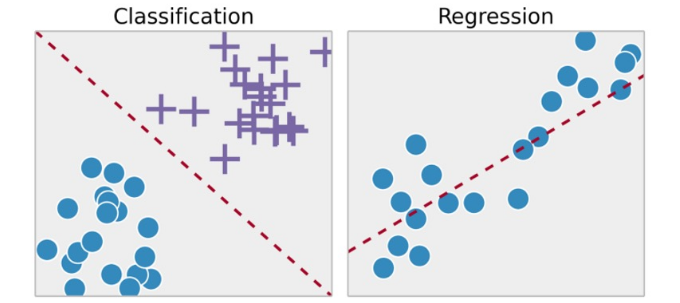)

<br>

## **2.1 - Introducción**

Los modelos de este tipo de tarea pertenecen además a la categorías de modelos de aprendizaje supervisado tienen como objetivo predecir una **VARIABLE CATEGÓRICA**

<Axes: title={'center': 'Horas de estudio'}, ylabel='Aprobado'>

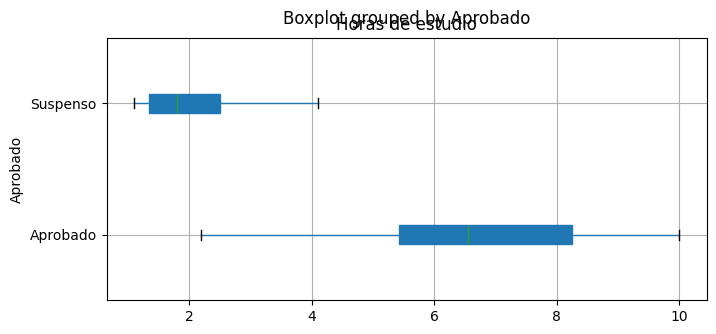

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

data = pd.DataFrame([
    {"Clase":"A","Horas de estudio":1.1,"Nota":2.1},
    {"Clase":"A","Horas de estudio":1.2,"Nota":2.5},
    {"Clase":"A","Horas de estudio":1.5,"Nota":3.0},
    {"Clase":"A","Horas de estudio":8.0,"Nota":7.2},
    {"Clase":"A","Horas de estudio":3.2,"Nota":5.0},
    {"Clase":"A","Horas de estudio":5.9,"Nota":7.2},
    {"Clase":"A","Horas de estudio":4.1,"Nota":4.9},
    {"Clase":"B","Horas de estudio":9.0,"Nota":8.4},
    {"Clase":"B","Horas de estudio":6.0,"Nota":6.4},
    {"Clase":"B","Horas de estudio":3.0,"Nota":4.2},
    {"Clase":"B","Horas de estudio":2.0,"Nota":4.0},
    {"Clase":"B","Horas de estudio":2.2,"Nota":5.7},
    {"Clase":"B","Horas de estudio":1.8,"Nota":3.0},
    {"Clase":"C","Horas de estudio":4.0,"Nota":6.4},
    {"Clase":"C","Horas de estudio":6.1,"Nota":8.5},
    {"Clase":"C","Horas de estudio":7.5,"Nota":10.0},
    {"Clase":"C","Horas de estudio":7.0,"Nota":7.6},
    {"Clase":"C","Horas de estudio":9.0,"Nota":9.2},
    {"Clase":"C","Horas de estudio":10.0,"Nota":8.5}
])


data["Aprobado"] = data["Nota"].apply(lambda x: "Suspenso" if x<5 else "Aprobado")
data.boxplot(column='Horas de estudio', by='Aprobado', patch_artist=True,  vert=False)

In [ ]:
data

,Clase,Horas de estudio,Nota,Aprobado
0,A,1.1,2.1,Suspenso
1,A,1.2,2.5,Suspenso
2,A,1.5,3.0,Suspenso
3,A,8.0,7.2,Aprobado
4,A,3.2,5.0,Aprobado
5,A,5.9,7.2,Aprobado
6,A,4.1,4.9,Suspenso
7,B,9.0,8.4,Aprobado
8,B,6.0,6.4,Aprobado
9,B,3.0,4.2,Suspenso


### **Tipos de clasificación**

Para que un modelo de ML sea capaz de predecir categorías, es necesario convertir la variable categórica a un valor numérico

<br>

**Binaria**

Cuando la categoría a predecir tiene únicamente 2 posibles valores.

In [ ]:
from sklearn.preprocessing import LabelEncoder

_data = data.copy()

# 1. Creamos el encoder
encoder = LabelEncoder().fit(_data["Aprobado"])

# 2. Nombres originales
labels = encoder.classes_
print(labels)

# 3. Codificamos la variable
_data["Aprobado"] = encoder.transform(_data["Aprobado"])
_data.head()

['Aprobado' 'Suspenso']


,Clase,Horas de estudio,Nota,Aprobado
0,A,1.1,2.1,1
1,A,1.2,2.5,1
2,A,1.5,3.0,1
3,A,8.0,7.2,0
4,A,3.2,5.0,0


<br>

**Clasificación Multicategoría**

Cuando la variable a predecir tiene N categorías. Existen 2 formas de convertirse a numérico

* **Factorize**: Da diferentes números a cada una de las categorías

In [ ]:
from sklearn.preprocessing import LabelEncoder

_data = data.copy()

# 1. Creamos el encoder
encoder = LabelEncoder().fit(_data["Clase"])

# 2. Nombres originales
labels = encoder.classes_
print(labels)

# 3. Codificamos la variable
_data["Clase"] = encoder.transform(_data["Clase"])
_data

['A' 'B' 'C']


,Clase,Horas de estudio,Nota,Aprobado
0,0,1.1,2.1,Suspenso
1,0,1.2,2.5,Suspenso
2,0,1.5,3.0,Suspenso
3,0,8.0,7.2,Aprobado
4,0,3.2,5.0,Aprobado
5,0,5.9,7.2,Aprobado
6,0,4.1,4.9,Suspenso
7,1,9.0,8.4,Aprobado
8,1,6.0,6.4,Aprobado
9,1,3.0,4.2,Suspenso


* **OneHotEncoder**: Crea una nueva columna para cata categoría

In [ ]:
from sklearn.preprocessing import LabelBinarizer

_data = data.copy()

# 1. Creamos el encoder
encoder = LabelBinarizer().fit(_data[["Clase"]])

# 2. Codificamos la variable
labels = encoder.classes_

# 3. Asignamos las nuevas varaibles
_data[encoder.classes_] = encoder.transform(_data[["Clase"]])
_data

,Clase,Horas de estudio,Nota,Aprobado,A,B,C
0,A,1.1,2.1,Suspenso,1,0,0
1,A,1.2,2.5,Suspenso,1,0,0
2,A,1.5,3.0,Suspenso,1,0,0
3,A,8.0,7.2,Aprobado,1,0,0
4,A,3.2,5.0,Aprobado,1,0,0
5,A,5.9,7.2,Aprobado,1,0,0
6,A,4.1,4.9,Suspenso,1,0,0
7,B,9.0,8.4,Aprobado,0,1,0
8,B,6.0,6.4,Aprobado,0,1,0
9,B,3.0,4.2,Suspenso,0,1,0


<br>

**Clafisificación Multilabel**

Cuando no solo hay varias categorías, sino que además se pueden dar a la vez

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

_data = pd.DataFrame([
    {"asignaturas":['Física', 'Química']},
    {"asignaturas":['Física']},
    {"asignaturas":['Matemáticas', 'Química']}
])

# 1. Creamos el encoder
encoder = MultiLabelBinarizer(sparse_output=False)

# 2. Codificamos la variable
encoded_vars = encoder.fit_transform(_data["asignaturas"])

# 3. Asignamos las nuevas varaibles
_data[encoder.classes_] = encoded_vars
_data.head()

,asignaturas,Física,Matemáticas,Química
0,"[Física, Química]",1,0,1
1,[Física],1,0,0
2,"[Matemáticas, Química]",0,1,1


> **NOTA**: *Para leer más sobre este tema dejamos la [siguiente documentación](https://scikit-learn.org/1.5/modules/multiclass.html).*

<br>

### Regresión logística

<Axes: xlabel='Horas de estudio', ylabel='Aprobado'>

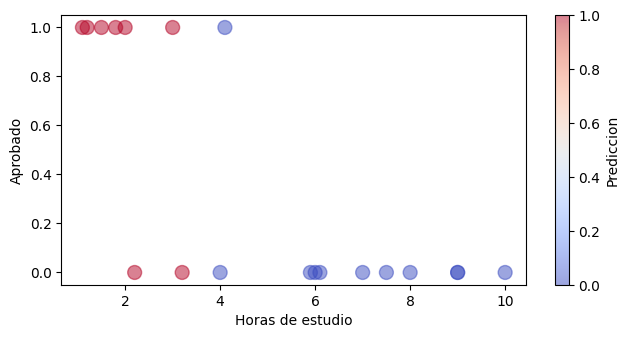

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

encoder = LabelEncoder()
data["Aprobado"] = encoder.fit_transform(data["Aprobado"])


model = LogisticRegression().fit(
    data[["Horas de estudio"]],
    data["Aprobado"])

data["Prediccion"] = model.predict(data[["Horas de estudio"]])

data.plot(
    kind='scatter',
    x='Horas de estudio',
    y='Aprobado',
    alpha=0.5,          # Transparencia para ver puntos encimados
    s=100,              # Tamaño de los puntos
    c='Prediccion',      # Color según si aprobó o no
    cmap='coolwarm',
)

In [ ]:
data[["Aprobado","Prediccion"]]

,Aprobado,Prediccion
0,1,1
1,1,1
2,1,1
3,0,0
4,0,1
5,0,0
6,1,0
7,0,0
8,0,0
9,1,1


<br>

## **2.2 - Evaluación**

 Durante el entrenamiento Función que usa el algoritmo durante el entrenamiento para aprender. Esta función mide "cuánto se equivoca" y en cada iteración trata de disminuirlo hasta acabar de entrenar

In [ ]:
y_pred = data["Prediccion"]
y_true = data["Aprobado"]

print(y_pred.values)
print(y_true.values)

[1 1 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0]
[1 1 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0]


### **Función de Loss**

Las funciones de los que usan los algoritmos de clasificación dependen de si el modelo es de clasificación binaria o clasificación múltiple


* **Binary Cross Entropy**

* **Categorical Cross Entropy**

* **Gini Coeficient**

In [ ]:
from sklearn.metrics import log_loss

print("CrossEntropy:\t",log_loss(y_true, y_pred))

CrossEntropy:	 5.6911031667027085


### **Métricas**

**Confusion Matrix**: La matriz de confusión compara valores predichos y reales en una misma matriz


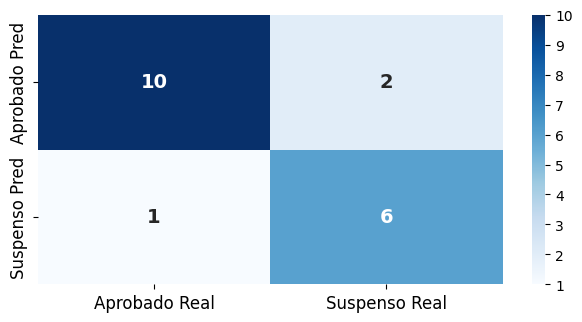

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

# Matriz de confusión
cm = confusion_matrix(
    y_true,
    y_pred,
)

# Grafica
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # annot_kws ajusta el tamaño de los números dentro de las celdas
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=[f"{c} Real" for c in encoder.classes_],
    yticklabels=[f"{c} Pred" for c in encoder.classes_]
)

# Ajustar el tamaño de los textos en los ejes (X e Y)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=90)

plt.show()


**Accuracy vs Precission vs Recall vs F1-Score**: 4 métricas que miden "cómo de preciso es el modelo, de diferentes formas

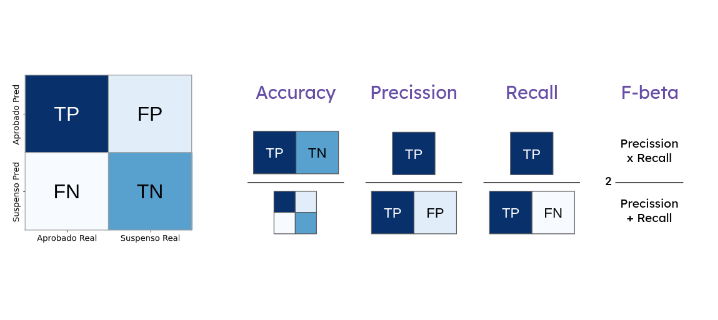

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        [encoder.classes_[i] for i in y_true],
        [encoder.classes_[i] for i in y_pred],
        labels=encoder.classes_,
    )
)

              precision    recall  f1-score   support

    Aprobado       0.91      0.83      0.87        12
    Suspenso       0.75      0.86      0.80         7

    accuracy                           0.84        19
   macro avg       0.83      0.85      0.83        19
weighted avg       0.85      0.84      0.84        19



<br>

## **2.3 - Modelos**

### **Dataset - Iris**

El dataset de Iris es un dataset de 150 registros de flores de 3 especies. Es un dataset muy común para empezar a aprender Machine Learning.

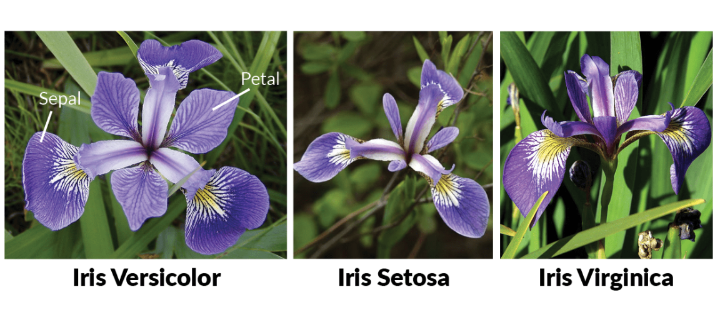

In [ ]:
import pandas as pd

url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
data = pd.read_csv(url)
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Para poder usarlo con un modelo de clasificación tenemos que convertir la variable `species` a un formato numérico para ello usamos la función factorize de pandas

In [ ]:
labels = encoder.classes_
labels

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Creamos el encoder
encoder = LabelEncoder().fit(data["species"])

# 2. Nombres originales
labels = encoder.classes_
print(labels)

# 3. Codificamos la variable
data["species"] = encoder.transform(data["species"])
data.head()

[0 1 2]


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("species", axis=1)
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0 )

<br>

### **RandomForest Classifier**

**Entrenamiento**

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=0,
).fit(X_train,y_train)


<br>

**Predicción**

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [ ]:
y_pred_proba = model.predict_proba(X_test)
print(y_pred_proba[0:5])

[[0.         0.016      0.984     ]
 [0.         0.95845238 0.04154762]
 [1.         0.         0.        ]
 [0.         0.00533333 0.99466667]
 [1.         0.         0.        ]]


<br>

**Evaluación**

In [ ]:
from sklearn.metrics import confusion_matrix
print('confusion matrix\n',confusion_matrix(y_test,y_pred))

confusion matrix
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        [encoder.classes_[i] for i in y_test],
        [encoder.classes_[i] for i in y_pred],
        labels=encoder.classes_,
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<br>

### **Support Vector Machine**

**Entrenamiento**

In [ ]:
import pandas as pd
from sklearn.svm import SVC

model = SVC(
    probability=True
).fit(X_train,y_train)

<br>

**Predicción**

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [ ]:
y_pred_proba = model.predict_proba(X_test)
print(y_pred_proba[0:5])

[[0.00914812 0.03579392 0.95505796]
 [0.01089568 0.97785763 0.01124669]
 [0.97164035 0.01671207 0.01164758]
 [0.00980414 0.00540283 0.98479303]
 [0.9645424  0.02419504 0.01126256]]


<br>

**Evaluación**

In [ ]:
from sklearn.metrics import confusion_matrix

print('confusion matrix\n',confusion_matrix(y_test,y_pred))

confusion matrix
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        [encoder.classes_[i] for i in y_test],
        [encoder.classes_[i] for i in y_pred],
        labels=encoder.classes_,
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<br>

### **Naive Bayes Classifier**

![]( 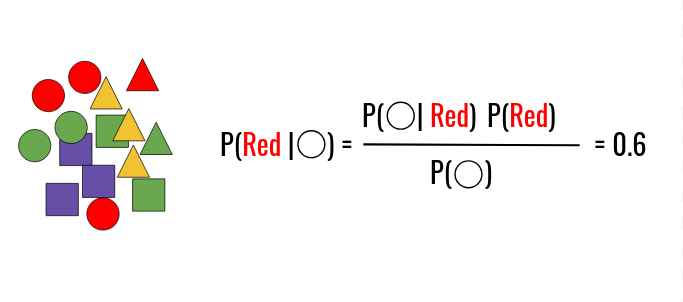)

**Entrenamiento**

In [ ]:
from sklearn.naive_bayes import GaussianNB


model = GaussianNB().fit(X_train,y_train)

<br>

**Predicción**

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[2 1 0 2 0 2 0 1 1 1 1 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


In [ ]:
y_pred_proba = model.predict_proba(X_test)
print(y_pred_proba[0:5])

[[4.01149696e-229 2.18878438e-006 9.99997811e-001]
 [4.22169416e-082 9.99998304e-001 1.69618390e-006]
 [1.00000000e+000 7.16284995e-019 3.68554763e-028]
 [8.35284952e-304 1.04649020e-006 9.99998954e-001]
 [1.00000000e+000 8.66468390e-017 4.25746157e-027]]


<br>

**Evaluación**

In [ ]:
from sklearn.metrics import confusion_matrix

print('confusion matrix\n',confusion_matrix(y_test,y_pred))

confusion matrix
 [[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        [encoder.classes_[i] for i in y_test],
        [encoder.classes_[i] for i in y_pred],
        labels=encoder.classes_,
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.93      1.00      0.96        13
           2       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



<br>

# **3. - Clustering - Aprendizaje No Supervisado**


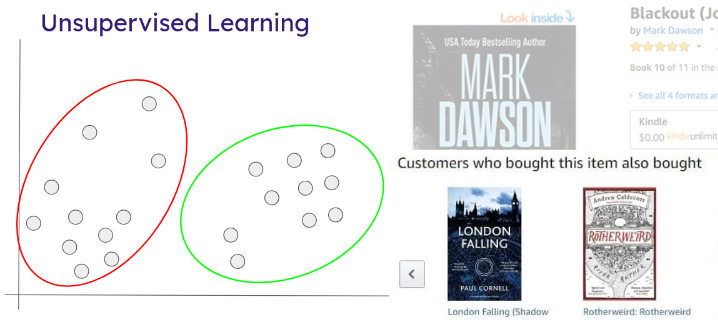

Los algoritmos más comunes de aprendizaje no supervisado son los algoritmos de clustering y los algoritmos de reducción de dimensionalidad:

<br>

* **Clustering**: Tienen como objetivo separar un conjunto de datos en diferentes categorías. Por ejemplo, a partir de datos sociodemográficos de la población encontrar los diferentes "arquetipos" de personas que hay.


* **Sistemas de recomendación**: Tienen como objetivo buscar elementos similares a otros dentro de un dataset. El concepto de "similaridad" depende de cómo se defina la cercanía entre  elementos y esto depende de una función de distancia.


* **Reducción de dimensionalidad**: Hay veces que tenemos conjuntos de datos que tienen muchas variables y queremos reducir el número de variables sin perder información relevante. Los algoritmos de reducción de dimensionalidad nos ayudan a reducir el número de variables sin perder información.

Estos dos últimos los veremos más adelante ya que es común usarlos en la computación lingüistica tradicional. En la sesión de hoy vamos a centrarnos en los algoritmos de clustering

<Axes: xlabel='Horas de estudio', ylabel='Nota'>

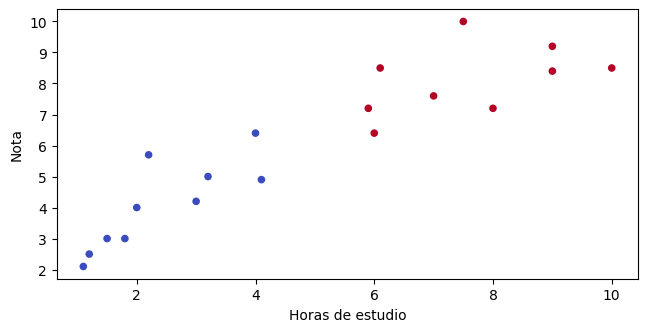

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

data = pd.DataFrame([
    {"Clase":"A","Horas de estudio":1.1,"Nota":2.1},
    {"Clase":"A","Horas de estudio":1.2,"Nota":2.5},
    {"Clase":"A","Horas de estudio":1.5,"Nota":3.0},
    {"Clase":"A","Horas de estudio":8.0,"Nota":7.2},
    {"Clase":"A","Horas de estudio":3.2,"Nota":5.0},
    {"Clase":"A","Horas de estudio":5.9,"Nota":7.2},
    {"Clase":"A","Horas de estudio":4.1,"Nota":4.9},
    {"Clase":"B","Horas de estudio":9.0,"Nota":8.4},
    {"Clase":"B","Horas de estudio":6.0,"Nota":6.4},
    {"Clase":"B","Horas de estudio":3.0,"Nota":4.2},
    {"Clase":"B","Horas de estudio":2.0,"Nota":4.0},
    {"Clase":"B","Horas de estudio":2.2,"Nota":5.7},
    {"Clase":"B","Horas de estudio":1.8,"Nota":3.0},
    {"Clase":"C","Horas de estudio":4.0,"Nota":6.4},
    {"Clase":"C","Horas de estudio":6.1,"Nota":8.5},
    {"Clase":"C","Horas de estudio":7.5,"Nota":10.0},
    {"Clase":"C","Horas de estudio":7.0,"Nota":7.6},
    {"Clase":"C","Horas de estudio":9.0,"Nota":9.2},
    {"Clase":"C","Horas de estudio":10.0,"Nota":8.5}
])

X=data.drop("Clase",axis=1)

X["cluster"] = KMeans(n_clusters=2).fit_predict(X)

X.plot(
    kind="scatter",
    x="Horas de estudio",
    y="Nota",
    c="cluster",
    cmap='coolwarm',
    colorbar=False,
)

### **Dataset - Iris sin categorías**

Aunque el dataset de iris tiene categorías, por fines únicamente didácticos, vamos a suponer que no tuviese la categoría `species` y vamos a ver si los modelos de clustering son capaces aprender categorías que se parezcan a la variable `species`

In [ ]:
import pandas as pd

url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
data = pd.read_csv(url)

X = data.drop("species", axis=1)
source_labels = LabelEncoder().fit_transform(data["species"])
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


<br>

### **Kmeans**

**Entrenamiento**

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3).fit(X)
model_labels = model.labels_
print(model_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


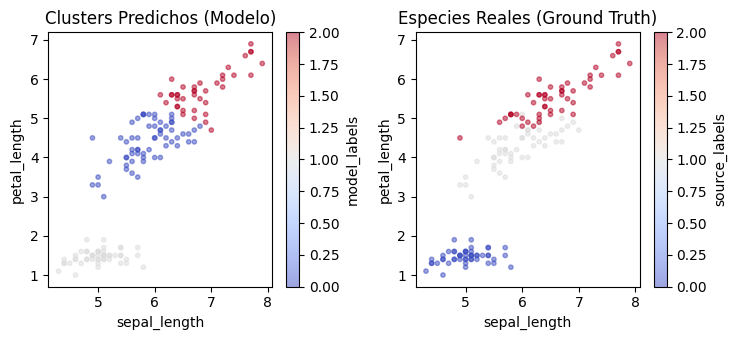

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

_data = data.copy()
_data["model_labels"] = model_labels
_data["source_labels"] = source_labels

# Creamos una figura con 2 subgráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2)

# Gráfica 1: Resultados del Modelo (Clustering)
_data.plot(
    kind='scatter',
    x='sepal_length',
    y='petal_length',
    c='model_labels',
    cmap='coolwarm',
    s=10,
    alpha=0.5,
    ax=ax1,             # <--- Importante: dibujar en el primer eje
    sharex=False
)
ax1.set_title("Clusters Predichos (Modelo)")

# Gráfica 2: Realidad (Especies)
_data.plot(
    kind='scatter',
    x='sepal_length',
    y='petal_length',
    c='source_labels',
    cmap='coolwarm',
    s=10,
    alpha=0.5,
    ax=ax2,             # <--- Importante: dibujar en el segundo eje
    sharex=False
)
ax2.set_title("Especies Reales (Ground Truth)")

plt.tight_layout()
plt.show()

**Métricas**

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

silhouette_avg = silhouette_score(X, model_labels)
print("Silhouette Score:", silhouette_avg)

ari_score = adjusted_rand_score(source_labels, model_labels)
print("Adjusted Rand Index (ARI):", ari_score)

Silhouette Score: 0.5509643746707443
Adjusted Rand Index (ARI): 0.7163421126838476


<br>

### **DBSCAN**

**Entrenamiento**

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN

model = DBSCAN().fit(X)
model_labels = model.labels_
model_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

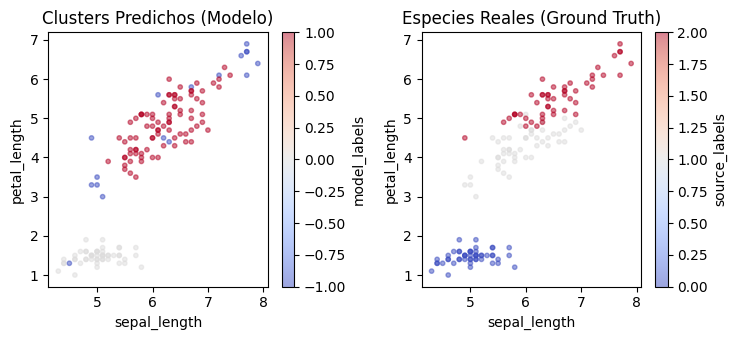

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (7.5,3.5)

_data = data.copy()
_data["model_labels"] = model_labels
_data["source_labels"] = source_labels

# Creamos una figura con 2 subgráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2)

# Gráfica 1: Resultados del Modelo (Clustering)
_data.plot(
    kind='scatter',
    x='sepal_length',
    y='petal_length',
    c='model_labels',
    cmap='coolwarm',
    s=10,
    alpha=0.5,
    ax=ax1,             # <--- Importante: dibujar en el primer eje
    sharex=False
)
ax1.set_title("Clusters Predichos (Modelo)")

# Gráfica 2: Realidad (Especies)
_data.plot(
    kind='scatter',
    x='sepal_length',
    y='petal_length',
    c='source_labels',
    cmap='coolwarm',
    s=10,
    alpha=0.5,
    ax=ax2,             # <--- Importante: dibujar en el segundo eje
    sharex=False
)
ax2.set_title("Especies Reales (Ground Truth)")

plt.tight_layout()
plt.show()

**Métricas**

In [ ]:
silhouette_avg = silhouette_score(X, model_labels)
print("Silhouette Score:", silhouette_avg)

ari_score = adjusted_rand_score(source_labels, model_labels)
print("Adjusted Rand Index (ARI):", ari_score)

Silhouette Score: 0.485842354600955
Adjusted Rand Index (ARI): 0.5206185241703302


> **NOTA**: Para ver de forma interactiva como funcionan estos y otros algoritmos de clustering recomendamos visitar la siguiente página web: https://clustering-visualizer.web.app/

<br>

# Ejercicio - Penguins dataset

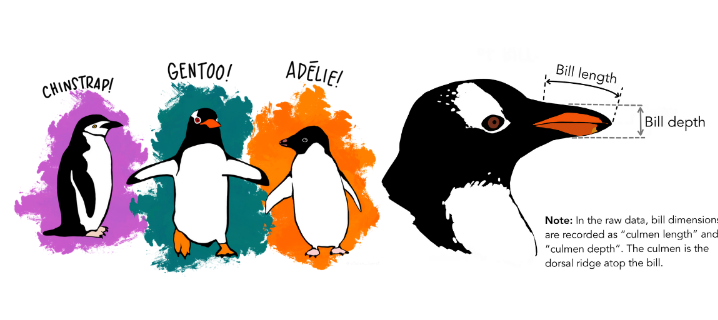

Un dataset como el de Iris, pero de pingüinos. Es conocido por ser una evolución estadísticamente más interesante. Para más información, leer la [documentación oficial](https://allisonhorst.github.io/palmerpenguins/)

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## Tarea 1 - Clasificador de Species

Para ello tenemos que tener en cuenta las siguientes cosas

* **Entender los datos**: leer la documentación para saber qué es cada variable

* **Limpieza de datos**: Hay valores nulos

* **Preprocesar datos**: Hay variables categóricas tanto en las features como en el target, hay que ver cómo preprocesarlos

## Tarea 2 - Clustering

Hacer clustering sin la variable espacie para ver "qué especies de pingüinos descubrimos"